In [17]:
import pandas as pd

oct_df = pd.read_csv("2019-Oct.csv", nrows=100000)
nov_df = pd.read_csv("2019-Nov.csv", nrows=100000)

df = pd.concat([oct_df, nov_df], ignore_index=True)

print(df.shape)
df.head()

(200000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [21]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True, errors='coerce')

df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

df['event_type'] = df['event_type'].astype('category')
df['category_code'] = df['category_code'].astype('category')
df['brand'] = df['brand'].astype('category')

In [23]:
total_users = df['user_id'].nunique()
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()
no_purchase_users = total_users - purchase_users

print("Total Users:", total_users)
print("Purchase Users:", purchase_users)
print("No Purchase %:", no_purchase_users / total_users)

Total Users: 40822
Purchase Users: 2484
No Purchase %: 0.939150458086326


In [25]:
funnel = df['event_type'].value_counts()

views = funnel.get('view', 0)
carts = funnel.get('cart', 0)
purchases = funnel.get('purchase', 0)

print("View → Cart:", carts / views)
print("Cart → Purchase:", purchases / carts)
print("View → Purchase:", purchases / views)

View → Cart: 0.011838515252878701
Cart → Purchase: 1.3355034722222223
View → Purchase: 0.015810378226175245


In [27]:
df = df.sort_values(by=['user_id', 'event_time'])

user_events = df.groupby('user_id')['event_type'].apply(list)

def has_view(events):
    return 'view' in events

def has_cart_after_view(events):
    try:
        return events.index('cart') > events.index('view')
    except:
        return False

def has_purchase_after_cart(events):
    try:
        return events.index('purchase') > events.index('cart')
    except:
        return False

view_users = 0
cart_users = 0
purchase_users = 0

for events in user_events:
    if has_view(events):
        view_users += 1
        if has_cart_after_view(events):
            cart_users += 1
            if has_purchase_after_cart(events):
                purchase_users += 1

print("View → Cart:", cart_users / view_users)
print("Cart → Purchase:", purchase_users / cart_users)
print("View → Purchase:", purchase_users / view_users)

View → Cart: 0.03478942597447142
Cart → Purchase: 0.5190140845070422
View → Purchase: 0.0180562020726658


In [28]:
# Extract date
df['event_date'] = df['event_time'].dt.normalize()

# First purchase per user
first_purchase = df[df['event_type'] == 'purchase'] \
    .groupby('user_id')['event_date'] \
    .min() \
    .reset_index()

first_purchase = first_purchase.rename(columns={'event_date': 'first_purchase_date'})

# Merge
df = df.merge(first_purchase, on='user_id', how='left')

# Days since purchase
df['days_since_first_purchase'] = (df['event_date'] - df['first_purchase_date']).dt.days

# FIX: Only keep events AFTER purchase
df_purchase = df[
    (df['first_purchase_date'].notna()) &
    (df['event_date'] >= df['first_purchase_date'])
].copy()

# Cohort table
cohort = df_purchase.groupby(
    ['first_purchase_date', 'days_since_first_purchase']
)['user_id'].nunique().unstack()

# Normalize
cohort = cohort.divide(cohort.iloc[:, 0], axis=0)

cohort.head()

days_since_first_purchase,0.0,31.0
first_purchase_date,,
2019-10-01 00:00:00+00:00,1.0,0.016467
2019-11-01 00:00:00+00:00,1.0,NaN


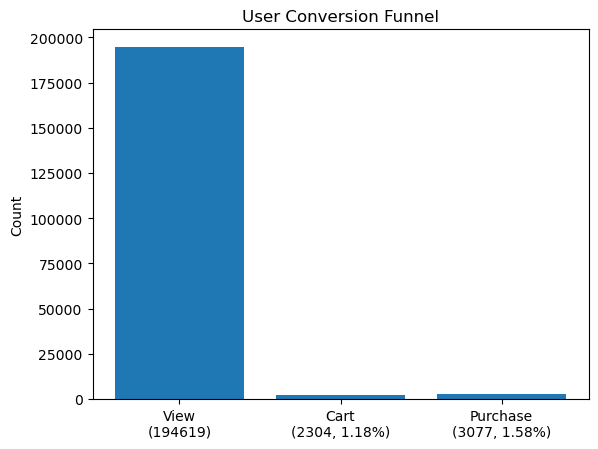

In [35]:
# Calculate percentages
view_to_cart = carts / views * 100
cart_to_purchase = purchases / carts * 100
view_to_purchase = purchases / views * 100

labels = [
    f"View\n({views})",
    f"Cart\n({carts}, {view_to_cart:.2f}%)",
    f"Purchase\n({purchases}, {view_to_purchase:.2f}%)"
]

plt.figure()
plt.bar(labels, values)
plt.title("User Conversion Funnel")
plt.ylabel("Count")
plt.show()